# ECG Disease Classification — A100 40GB GPU Maximized
### Multimodal Ensemble: CNN Image + Numerical ECG Features
**Research-Level Pipeline | Google Colab A100 | PyTorch 2.x**

**Cells in order:**
1. Install & imports
2. GPU verification
3. Config (edit paths here)
4. A100 PyTorch flags + seed
5. Transforms
6. Dataset class
7. Patient-wise split
8. WeightedRandomSampler
9. Model architecture
10. Training utilities (EarlyStopping, train_one_epoch, evaluate, train)
11. Evaluation metrics
12. Visualization
13. Inference function
14. ▶ RUN: build data → model → train → evaluate → inference


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 1 — Install dependencies (run once per Colab session)
!pip install -q tqdm scikit-learn matplotlib pandas numpy torchvision
!nvidia-smi  # verify A100 is attached


Wed May 20 03:59:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# =====================================================
# IMPORT LIBRARY
# =====================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image

from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error
)

In [ ]:
# =====================================================
# GPU CHECK
# =====================================================
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():

    gpu_name = torch.cuda.get_device_name(0)

    vram_gb = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024**3)
    )

    print(f"[GPU] {gpu_name}")

    print(f"[VRAM] {vram_gb:.1f} GB")

else:
    raise RuntimeError("CUDA NOT AVAILABLE")

CUDA Available: True
[GPU] Tesla T4
[VRAM] 14.6 GB


In [ ]:
# =====================================================
# CONFIG
# =====================================================
class Config:

    BASE_DIR = "/content/drive/MyDrive/DataSet/ptbdb/All_Assets"

    DATASET_DIR = os.path.join(
        BASE_DIR,
        "dataset_images_3class"
    )

    OUTPUT_DIR = os.path.join(
        BASE_DIR,
        "multitask_outputs"
    )

    TRAIN_CSV = os.path.join(
        BASE_DIR,
        "train.csv"
    )

    VAL_CSV = os.path.join(
        BASE_DIR,
        "val.csv"
    )

    TEST_CSV = os.path.join(
        BASE_DIR,
        "test.csv"
    )

    IMAGE_SIZE = 224

    BATCH_SIZE = 128

    EPOCHS = 20

    LEARNING_RATE = 1e-4

    NUM_WORKERS = 4

    PATIENCE = 7

    DEVICE = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

CFG = Config()

os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)

print("CONFIG READY")

CONFIG READY


In [ ]:
# =====================================================
# ECG FEATURE SCALER
# =====================================================

FEATURE_COLUMNS = [
    'HR',
    'RR',
    'PR',
    'QRS',
    'QT',
    'QTc',
    'AXIS',
    'RV5',
    'SV1',
    'R_plus_S'
]

train_df = pd.read_csv(CFG.TRAIN_CSV)

scaler = StandardScaler()

scaler.fit(
    train_df[FEATURE_COLUMNS]
)

# SAVE SCALER
joblib.dump(
    scaler,
    os.path.join(
        CFG.OUTPUT_DIR,
        "ecg_scaler.pkl"
    )
)

print("SCALER READY")

SCALER READY


In [ ]:
# =====================================================
# TRANSFORM
# =====================================================
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomRotation(5),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

print("TRANSFORM READY")

TRANSFORM READY


In [ ]:
# =====================================================
# ECG DATASET
# =====================================================
class ECGDataset(Dataset):

    def __init__(
        self,
        csv_file,
        image_dir,
        transform=None
    ):

        self.df = pd.read_csv(csv_file)

        self.image_dir = image_dir

        self.transform = transform

        self.label_map = {
            "Normal": 0,
            "Myocardial_Infarction": 1,
            "Other_Heart_Disease": 2
        }

        self.feature_cols = [
            'HR',
            'RR',
            'PR',
            'QRS',
            'QT',
            'QTc',
            'AXIS',
            'RV5',
            'SV1',
            'R_plus_S'
        ]

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        patient_id = row['patient_id']

        label_name = row['label']

        image_path = os.path.join(
            self.image_dir,
            label_name,
            f"{patient_id}.png"
        )

        if not os.path.exists(image_path):

            image_path = image_path.replace(
                ".png",
                ".jpg"
            )

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:

            image = self.transform(image)

        class_label = torch.tensor(
            self.label_map[label_name],
            dtype=torch.long
        )

        features = row[self.feature_cols].values.astype(np.float32)
        features_scaled = scaler.transform(
            [features]
        )[0]

        regression_target = torch.tensor(
            features_scaled,
            dtype=torch.float32
        )

        return (
            image,
            class_label,
            regression_target
        )

In [ ]:
# =====================================================
# DATASET
# =====================================================
train_dataset = ECGDataset(
    CFG.TRAIN_CSV,
    CFG.DATASET_DIR,
    transform=train_transform
)

val_dataset = ECGDataset(
    CFG.VAL_CSV,
    CFG.DATASET_DIR,
    transform=test_transform
)

test_dataset = ECGDataset(
    CFG.TEST_CSV,
    CFG.DATASET_DIR,
    transform=test_transform
)

In [ ]:
# =====================================================
# DATALOADER
# =====================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

class_names = [
    "Normal",
    "Myocardial_Infarction",
    "Other_Heart_Disease"
]

print("TRAIN :", len(train_dataset))
print("VAL :", len(val_dataset))
print("TEST :", len(test_dataset))


TRAIN : 362
VAL : 78
TEST : 78


In [ ]:
# =====================================================
# EARLY STOPPING
# =====================================================
class EarlyStopping:

    def __init__(
        self,
        patience=5,
        min_delta=0
    ):

        self.patience = patience

        self.min_delta = min_delta

        self.counter = 0

        self.best_loss = None

        self.early_stop = False

    def __call__(self, val_loss):

        if self.best_loss is None:

            self.best_loss = val_loss

        elif val_loss > self.best_loss - self.min_delta:

            self.counter += 1

            if self.counter >= self.patience:

                self.early_stop = True

        else:

            self.best_loss = val_loss

            self.counter = 0

In [ ]:
# =====================================================
# MULTITASK MODEL
# =====================================================
class MultiTaskModel(nn.Module):

    def __init__(
        self,
        backbone_name,
        num_classes=3,
        num_features=10
    ):

        super().__init__()

        self.backbone_name = backbone_name

        # =================================================
        # RESNET34
        # =================================================
        if backbone_name == "resnet34":

            backbone = models.resnet34(
                pretrained=True
            )

            in_features = backbone.fc.in_features

            self.feature_extractor = nn.Sequential(
                *list(backbone.children())[:-1]
            )

        # =================================================
        # VGG16
        # =================================================
        elif backbone_name == "vgg16":

            backbone = models.vgg16(
                pretrained=True
            )

            self.feature_extractor = backbone.features

            self.avgpool = backbone.avgpool

            self.vgg_classifier = nn.Sequential(
                *list(backbone.classifier.children())[:-1]
            )

            in_features = 4096

        # =================================================
        # DENSENET121
        # =================================================
        elif backbone_name == "densenet121":

            backbone = models.densenet121(
                pretrained=True
            )

            self.feature_extractor = backbone.features

            in_features = (
                backbone.classifier.in_features
            )

        # =================================================
        # OUTPUT HEAD
        # =================================================
        self.classifier = nn.Linear(
            in_features,
            num_classes
        )

        self.regressor = nn.Linear(
            in_features,
            num_features
        )

    def forward(self, x):

        # =================================================
        # RESNET34
        # =================================================
        if self.backbone_name == "resnet34":

            x = self.feature_extractor(x)

            x = torch.flatten(x,1)

        # =================================================
        # VGG16
        # =================================================
        elif self.backbone_name == "vgg16":

            x = self.feature_extractor(x)

            x = self.avgpool(x)

            x = torch.flatten(x,1)

            x = self.vgg_classifier(x)

        # =================================================
        # DENSENET121
        # =================================================
        elif self.backbone_name == "densenet121":

            x = self.feature_extractor(x)

            x = nn.functional.relu(x)

            x = nn.functional.adaptive_avg_pool2d(
                x,
                (1,1)
            )

            x = torch.flatten(x,1)

        class_output = self.classifier(x)


        regression_output = self.regressor(x)

        regression_output = torch.clamp(
            regression_output,
            min=-5,
            max=5
        )

        return (
            class_output,
            regression_output
        )

In [ ]:
# =====================================================
# TRAIN FUNCTION
# =====================================================
def train_model(model_name):

    print(f"\nTRAINING {model_name.upper()}")

    model = MultiTaskModel(
        backbone_name=model_name
    ).to(CFG.DEVICE)

    classification_criterion = nn.CrossEntropyLoss()

    regression_criterion = nn.HuberLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=CFG.LEARNING_RATE
    )

    scaler = torch.cuda.amp.GradScaler()

    early_stopping = EarlyStopping(
        patience=CFG.PATIENCE
    )

    best_acc = 0

    history_train_acc = []

    history_val_acc = []

    for epoch in range(CFG.EPOCHS):

        # =================================================
        # TRAIN
        # =================================================
        model.train()

        running_loss = 0

        correct = 0

        total = 0

        loop = tqdm(
            train_loader,
            desc=f"{model_name} Epoch {epoch+1}"
        )

        for (
            images,
            class_labels,
            reg_targets
        ) in loop:

            images = images.to(
                CFG.DEVICE,
                non_blocking=True
            )

            class_labels = class_labels.to(
                CFG.DEVICE,
                non_blocking=True
            )

            reg_targets = reg_targets.to(
                CFG.DEVICE,
                non_blocking=True
            )

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():

                class_outputs, reg_outputs = model(images)

                classification_loss = (
                    classification_criterion(
                        class_outputs,
                        class_labels
                    )
                )

                regression_loss = (
                    regression_criterion(
                        reg_outputs,
                        reg_targets
                    )
                )


                total_loss = (
                    classification_loss
                    +
                    0.25 * regression_loss
                )

            scaler.scale(total_loss).backward()

            scaler.step(optimizer)

            scaler.update()

            running_loss += total_loss.item()

            _, predicted = torch.max(
                class_outputs,
                1
            )

            total += class_labels.size(0)

            correct += (
                predicted == class_labels
            ).sum().item()

            loop.set_postfix({
                "Loss": total_loss.item(),
                "Acc": 100. * correct / total
            })

        train_acc = correct / total

        # =================================================
        # VALIDATION
        # =================================================
        model.eval()

        val_correct = 0

        val_total = 0

        val_loss = 0

        with torch.no_grad():

            for (
                images,
                class_labels,
                reg_targets
            ) in val_loader:

                images = images.to(
                    CFG.DEVICE,
                    non_blocking=True
                )

                class_labels = class_labels.to(
                    CFG.DEVICE,
                    non_blocking=True
                )

                reg_targets = reg_targets.to(
                    CFG.DEVICE,
                    non_blocking=True
                )

                with torch.cuda.amp.autocast():

                    class_outputs, reg_outputs = model(images)

                    classification_loss = (
                        classification_criterion(
                            class_outputs,
                            class_labels
                        )
                    )

                    regression_loss = (
                        regression_criterion(
                            reg_outputs,
                            reg_targets
                        )
                    )

                    total_batch_loss = (
                        classification_loss +
                        0.25 * regression_loss
                    )

                val_loss += total_batch_loss.item()

                _, predicted = torch.max(
                    class_outputs,
                    1
                )

                val_total += class_labels.size(0)

                val_correct += (
                    predicted == class_labels
                ).sum().item()

        val_acc = val_correct / val_total

        avg_val_loss = val_loss / len(val_loader)

        history_train_acc.append(train_acc)

        history_val_acc.append(val_acc)

        print(
            f"\n{model_name} "
            f"| Epoch {epoch+1}/{CFG.EPOCHS}"
            f"\nTrain Acc : {train_acc:.4f}"
            f"\nVal Acc   : {val_acc:.4f}"
            f"\nVal Loss  : {avg_val_loss:.4f}"
        )

        # =================================================
        # SAVE BEST MODEL
        # =================================================
        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                os.path.join(
                    CFG.OUTPUT_DIR,
                    f"best_{model_name}.pth"
                )
            )

            print("BEST MODEL SAVED")

        # =================================================
        # EARLY STOPPING
        # =================================================
        early_stopping(avg_val_loss)

        if early_stopping.early_stop:

            print(
                f"EARLY STOPPING "
                f"ON EPOCH {epoch+1}"
            )

            break

    return model

In [ ]:
# =====================================================
# TRAIN 3 MODELS
# =====================================================
vgg16_model = train_model("vgg16")

resnet34_model = train_model("resnet34")

densenet121_model = train_model("densenet121")

print("\nALL MODEL TRAINING FINISHED")

# =====================================================
# LOAD BEST MODEL
# =====================================================
vgg16_model = MultiTaskModel(
    "vgg16"
).to(CFG.DEVICE)

resnet34_model = MultiTaskModel(
    "resnet34"
).to(CFG.DEVICE)

densenet121_model = MultiTaskModel(
    "densenet121"
).to(CFG.DEVICE)

vgg16_model.load_state_dict(
    torch.load(
        os.path.join(
            CFG.OUTPUT_DIR,
            "best_vgg16.pth"
        )
    )
)

resnet34_model.load_state_dict(
    torch.load(
        os.path.join(
            CFG.OUTPUT_DIR,
            "best_resnet34.pth"
        )
    )
)

densenet121_model.load_state_dict(
    torch.load(
        os.path.join(
            CFG.OUTPUT_DIR,
            "best_densenet121.pth"
        )
    )
)

vgg16_model.eval()

resnet34_model.eval()

densenet121_model.eval()

print("BEST MODEL LOADED")


TRAINING VGG16


vgg16 Epoch 1: 100%|██████████| 3/3 [00:21<00:00,  7.23s/it, Loss=1.35, Acc=19.3]



vgg16 | Epoch 1/20
Train Acc : 0.1934
Val Acc   : 0.7051
Val Loss  : 0.9080
BEST MODEL SAVED


vgg16 Epoch 2: 100%|██████████| 3/3 [00:30<00:00, 10.33s/it, Loss=0.894, Acc=71]



vgg16 | Epoch 2/20
Train Acc : 0.7099
Val Acc   : 0.7051
Val Loss  : 0.9088


...


densenet121 | Epoch 18/20
Train Acc : 0.9862
Val Acc   : 0.9744
Val Loss  : 0.1743


densenet121 Epoch 19: 100%|██████████| 3/3 [00:18<00:00,  6.22s/it, Loss=0.13, Acc=97.8]



densenet121 | Epoch 19/20
Train Acc : 0.9779
Val Acc   : 1.0000
Val Loss  : 0.1178
BEST MODEL SAVED


densenet121 Epoch 20: 100%|██████████| 3/3 [00:19<00:00,  6.44s/it, Loss=0.127, Acc=99.4]



densenet121 | Epoch 20/20
Train Acc : 0.9945
Val Acc   : 1.0000
Val Loss  : 0.1216

ALL MODEL TRAINING FINISHED
BEST MODEL LOADED


In [ ]:
# =====================================================
# ENSEMBLE EVALUATION
# =====================================================
from sklearn.metrics import mean_absolute_error

all_preds = []

all_labels = []

all_reg_preds = []

all_reg_targets = []

with torch.no_grad():

    for (
        images,
        class_labels,
        reg_targets
    ) in tqdm(test_loader):

        images = images.to(CFG.DEVICE)

        with torch.cuda.amp.autocast():

            # =========================================
            # MODEL OUTPUT
            # =========================================
            out1, reg1 = vgg16_model(images)

            out2, reg2 = resnet34_model(images)

            out3, reg3 = densenet121_model(images)

            # =========================================
            # CLASSIFICATION ENSEMBLE
            # =========================================
            probs1 = torch.softmax(out1, dim=1)

            probs2 = torch.softmax(out2, dim=1)

            probs3 = torch.softmax(out3, dim=1)

            avg_probs = (
                probs1 +
                probs2 +
                probs3
            ) / 3

            # =========================================
            # REGRESSION ENSEMBLE
            # =========================================
            avg_regression = (
                reg1 +
                reg2 +
                reg3
            ) / 3

        # =========================================
        # CLASS PREDICTION
        # =========================================
        _, predicted = torch.max(
            avg_probs,
            1
        )

        all_preds.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            class_labels.numpy()
        )

        # =========================================
        # SAVE REGRESSION
        # =========================================
        all_reg_preds.extend(
            avg_regression.cpu().numpy()
        )

        all_reg_targets.extend(
            reg_targets.numpy()
        )

# =====================================================
# CLASSIFICATION METRIC
# =====================================================
acc = accuracy_score(
    all_labels,
    all_preds
)

print(f"\nENSEMBLE ACC : {acc:.4f}")

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

# =====================================================
# INVERSE SCALER
# =====================================================
all_reg_preds = scaler.inverse_transform(
    np.array(all_reg_preds)
)

all_reg_targets = scaler.inverse_transform(
    np.array(all_reg_targets)
)

# =====================================================
# REGRESSION METRIC
# =====================================================
mae = mean_absolute_error(
    all_reg_targets,
    all_reg_preds
)

print(f"\nREGRESSION MAE : {mae:.4f}")

feature_names = [
    'HR',
    'RR',
    'PR',
    'QRS',
    'QT',
    'QTc',
    'AXIS',
    'RV5',
    'SV1',
    'R_plus_S'
]

print("\nMAE PER FEATURE")
print("="*40)

for i, name in enumerate(feature_names):

    mae_feature = np.mean(
        np.abs(
            all_reg_targets[:, i]
            -
            all_reg_preds[:, i]
        )
    )

    print(f"{name:<10}: {mae_feature:.4f}")

100%|██████████| 1/1 [00:10<00:00, 10.95s/it]


ENSEMBLE ACC : 0.9744

CLASSIFICATION REPORT

                       precision    recall  f1-score   support

               Normal       1.00      1.00      1.00        12
Myocardial_Infarction       0.97      1.00      0.98        56
  Other_Heart_Disease       1.00      0.80      0.89        10

             accuracy                           0.97        78
            macro avg       0.99      0.93      0.96        78
         weighted avg       0.98      0.97      0.97        78


REGRESSION MAE : 4.6438


In [ ]:
# =====================================================
# METRIC
# =====================================================
acc = accuracy_score(
    all_labels,
    all_preds
)

print(f"\nENSEMBLE ACC : {acc:.4f}")

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)


ENSEMBLE ACC : 0.9744

CLASSIFICATION REPORT

                       precision    recall  f1-score   support

               Normal       1.00      1.00      1.00        12
Myocardial_Infarction       0.97      1.00      0.98        56
  Other_Heart_Disease       1.00      0.80      0.89        10

             accuracy                           0.97        78
            macro avg       0.99      0.93      0.96        78
         weighted avg       0.98      0.97      0.97        78



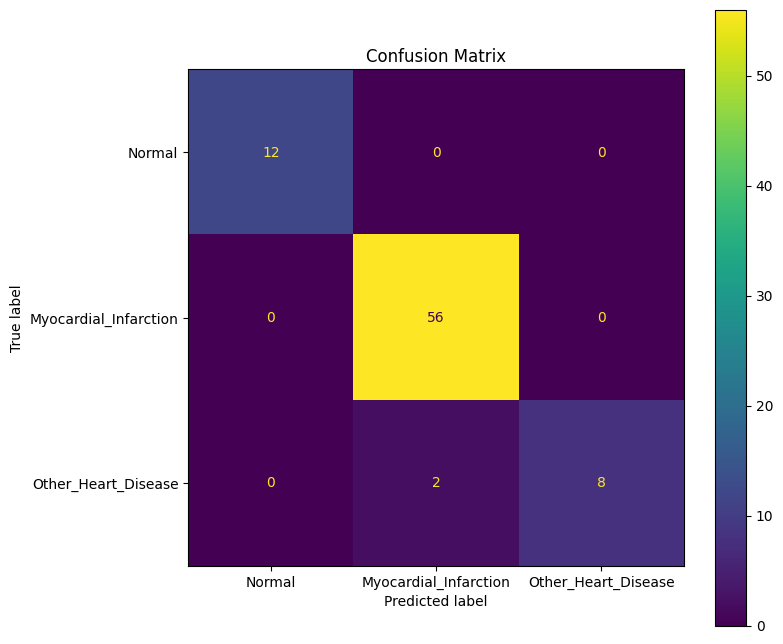

In [ ]:
# =====================================================
# CONFUSION MATRIX
# =====================================================
cm = confusion_matrix(
    all_labels,
    all_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(ax=ax)

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# =====================================================
# SAVE REPORT
# =====================================================
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

df_report.to_csv(
    os.path.join(
        CFG.OUTPUT_DIR,
        "classification_report.csv"
    )
)

print("REPORT SAVED")

REPORT SAVED



PREDICTION RESULT
CLASS : Normal
HR        : 65.1285
RR        : 0.9325
PR        : 0.1076
QRS       : 0.1693
QT        : 0.4599
QTc       : 0.4684
AXIS      : 46.5296
RV5       : 1.1748
SV1       : 0.7095
R_plus_S  : 1.9041


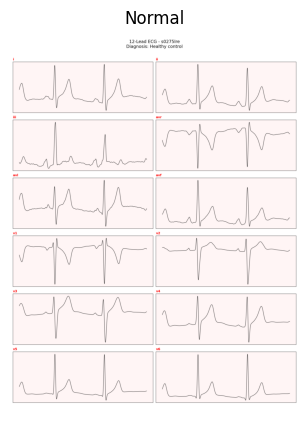

In [ ]:
# =====================================================
# SINGLE IMAGE PREDICTION
# =====================================================
image_path = os.path.join(
    CFG.DATASET_DIR,
    "Normal",
    os.listdir(
        os.path.join(
            CFG.DATASET_DIR,
            "Normal"
        )
    )[0]
)

image = Image.open(
    image_path
).convert("RGB")

input_tensor = test_transform(image)

input_tensor = input_tensor.unsqueeze(0).to(
    CFG.DEVICE
)

with torch.no_grad():

    out1, reg1 = vgg16_model(input_tensor)

    out2, reg2 = resnet34_model(input_tensor)

    out3, reg3 = densenet121_model(input_tensor)

    probs1 = torch.softmax(out1, dim=1)

    probs2 = torch.softmax(out2, dim=1)

    probs3 = torch.softmax(out3, dim=1)

    avg_probs = (
        probs1 +
        probs2 +
        probs3
    ) / 3

    avg_regression = (
        reg1 +
        reg2 +
        reg3
    ) / 3

    pred = torch.argmax(
        avg_probs,
        dim=1
    )

predicted_class = class_names[
    pred.item()
]

scaled_features = avg_regression.cpu().numpy()

ecg_features = scaler.inverse_transform(
    scaled_features
)[0]

ecg_features[0] = np.clip(ecg_features[0], 30, 220)     # HR
ecg_features[1] = np.clip(ecg_features[1], 0.3, 2.0)    # RR
ecg_features[2] = np.clip(ecg_features[2], 0.08, 0.30)  # PR
ecg_features[3] = np.clip(ecg_features[3], 0.06, 0.20)  # QRS
ecg_features[4] = np.clip(ecg_features[4], 0.20, 0.60)  # QT
ecg_features[5] = np.clip(ecg_features[5], 0.30, 0.60)  # QTc
ecg_features[6] = np.clip(ecg_features[6], -180, 180)   # AXIS
ecg_features[7] = np.clip(ecg_features[7], 0, 10)       # RV5
ecg_features[8] = np.clip(ecg_features[8], 0, 10)       # SV1
ecg_features[9] = np.clip(ecg_features[9], 0, 20)       # R+S

feature_names = [
    'HR',
    'RR',
    'PR',
    'QRS',
    'QT',
    'QTc',
    'AXIS',
    'RV5',
    'SV1',
    'R_plus_S'
]

print("\nPREDICTION RESULT")

print("="*50)

print("CLASS :", predicted_class)

print("="*50)

for name, value in zip(
    feature_names,
    ecg_features
):

    print(f"{name:<10}: {value:.4f}")

plt.figure(figsize=(8,5))

plt.imshow(image)

plt.title(predicted_class)

plt.axis("off")

plt.show()


ECG ANALYSIS RESULT
Prediction : Myocardial_Infarction
Confidence : 78.33%
--------------------------------------------------
ECG FEATURES
--------------------------------------------------
HR        : 80.5000
RR        : 0.8726
PR        : 0.1215
QRS       : 0.1697
QT        : 0.3672
QTc       : 0.4207
AXIS      : 15.1172
RV5       : 0.9380
SV1       : 0.9531
R_plus_S  : 1.9414


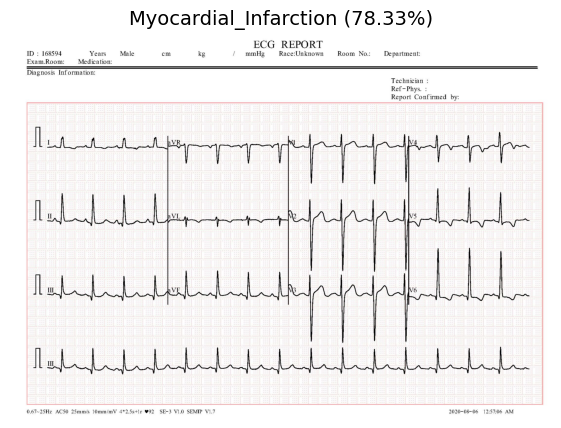

In [ ]:
# =====================================================
# TEST GAMBAR ECG BARU (DI LUAR DATASET)
# FIX INVERSE TRANSFORM REGRESSION
# =====================================================

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch

# =====================================================
# PATH ECG BARU
# =====================================================
image_path = "/content/drive/MyDrive/DataSet/ptbdb/Test_Img.jpg"

# =====================================================
# LOAD IMAGE
# =====================================================
image = Image.open(image_path).convert("RGB")

# =====================================================
# TRANSFORM
# =====================================================
input_tensor = test_transform(image)

input_tensor = input_tensor.unsqueeze(0).to(CFG.DEVICE)

# =====================================================
# INFERENCE
# =====================================================
with torch.no_grad():

    with torch.cuda.amp.autocast():

        # ==============================
        # VGG16
        # ==============================
        out1, reg1 = vgg16_model(input_tensor)

        # ==============================
        # RESNET34
        # ==============================
        out2, reg2 = resnet34_model(input_tensor)

        # ==============================
        # DENSENET121
        # ==============================
        out3, reg3 = densenet121_model(input_tensor)

        # ==============================
        # CLASSIFICATION ENSEMBLE
        # ==============================
        probs1 = torch.softmax(out1, dim=1)

        probs2 = torch.softmax(out2, dim=1)

        probs3 = torch.softmax(out3, dim=1)

        avg_probs = (
            probs1 +
            probs2 +
            probs3
        ) / 3

        # ==============================
        # REGRESSION ENSEMBLE
        # ==============================
        avg_regression = (
            reg1 +
            reg2 +
            reg3
        ) / 3

# =====================================================
# CLASS PREDICTION
# =====================================================
pred = torch.argmax(avg_probs, dim=1)

confidence = torch.max(avg_probs).item() * 100

predicted_class = class_names[pred.item()]

# =====================================================
# FEATURE NAMES
# =====================================================
feature_names = [
    'HR',
    'RR',
    'PR',
    'QRS',
    'QT',
    'QTc',
    'AXIS',
    'RV5',
    'SV1',
    'R_plus_S'
]

# =====================================================
# INVERSE SCALER
# =====================================================
scaled_features = avg_regression.cpu().numpy()

ecg_features = scaler.inverse_transform(
    scaled_features
)[0]

# =====================================================
# CLIPPING AGAR REALISTIS
# =====================================================
ecg_features[0] = np.clip(ecg_features[0], 30, 220)     # HR
ecg_features[1] = np.clip(ecg_features[1], 0.3, 2.0)    # RR
ecg_features[2] = np.clip(ecg_features[2], 0.08, 0.30)  # PR
ecg_features[3] = np.clip(ecg_features[3], 0.06, 0.20)  # QRS
ecg_features[4] = np.clip(ecg_features[4], 0.20, 0.60)  # QT
ecg_features[5] = np.clip(ecg_features[5], 0.30, 0.60)  # QTc
ecg_features[6] = np.clip(ecg_features[6], -180, 180)   # AXIS
ecg_features[7] = np.clip(ecg_features[7], 0, 10)       # RV5
ecg_features[8] = np.clip(ecg_features[8], 0, 10)       # SV1
ecg_features[9] = np.clip(ecg_features[9], 0, 20)       # R+S

# =====================================================
# PRINT RESULT
# =====================================================
print("\n" + "="*50)

print("ECG ANALYSIS RESULT")

print("="*50)

print(f"Prediction : {predicted_class}")

print(f"Confidence : {confidence:.2f}%")

print("-"*50)

print("ECG FEATURES")

print("-"*50)

for name, value in zip(
    feature_names,
    ecg_features
):

    print(f"{name:<10}: {value:.4f}")

print("="*50)

# =====================================================
# VISUALIZATION
# =====================================================
plt.figure(figsize=(10,5))

plt.imshow(image)

plt.title(
    f"{predicted_class} "
    f"({confidence:.2f}%)",
    fontsize=14
)

plt.axis("off")

plt.show()

In [ ]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

df_report.to_csv(
    os.path.join(
        CFG.OUTPUT_DIR,
        "classification_report.csv"
    )
)

print("REPORT SAVED")

REPORT SAVED


# =====================================================
# FULL REGRESSION EVALUATION
# MAE TOTAL + MAE PER FEATURE
# =====================================================

In [ ]:
# =====================================================
# FULL EVALUATION
# LOAD BEST MODEL ONLY (NO RETRAIN)
# MULTITASK ECG MODEL
# =====================================================

import os
import joblib
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import models

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_absolute_error
)

# =====================================================
# DEVICE
# =====================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE :", DEVICE)

# =====================================================
# PATH CONFIG
# =====================================================

BASE_DIR = "/content/drive/MyDrive/DataSet/ptbdb/All_Assets"

MODEL_DIR = os.path.join(
    BASE_DIR,
    "multitask_outputs"
)

# =====================================================
# LOAD SCALER
# =====================================================

scaler = joblib.load(
    os.path.join(
        MODEL_DIR,
        "ecg_scaler.pkl"
    )
)

print("SCALER LOADED")

# =====================================================
# MULTITASK MODEL
# =====================================================

class MultiTaskModel(nn.Module):

    def __init__(
        self,
        backbone_name,
        num_classes=3,
        num_features=10
    ):

        super().__init__()

        self.backbone_name = backbone_name

        # =================================================
        # RESNET34
        # =================================================
        if backbone_name == "resnet34":

            backbone = models.resnet34(
                pretrained=False
            )

            in_features = backbone.fc.in_features

            self.feature_extractor = nn.Sequential(
                *list(backbone.children())[:-1]
            )

        # =================================================
        # VGG16
        # =================================================
        elif backbone_name == "vgg16":

            backbone = models.vgg16(
                pretrained=False
            )

            self.feature_extractor = backbone.features

            self.avgpool = backbone.avgpool

            self.vgg_classifier = nn.Sequential(
                *list(backbone.classifier.children())[:-1]
            )

            in_features = 4096

        # =================================================
        # DENSENET121
        # =================================================
        elif backbone_name == "densenet121":

            backbone = models.densenet121(
                pretrained=False
            )

            self.feature_extractor = backbone.features

            in_features = (
                backbone.classifier.in_features
            )

        # =================================================
        # OUTPUT HEAD
        # =================================================

        self.classifier = nn.Linear(
            in_features,
            num_classes
        )

        self.regressor = nn.Linear(
            in_features,
            num_features
        )

    def forward(self, x):

        # =================================================
        # RESNET34
        # =================================================
        if self.backbone_name == "resnet34":

            x = self.feature_extractor(x)

            x = torch.flatten(x,1)

        # =================================================
        # VGG16
        # =================================================
        elif self.backbone_name == "vgg16":

            x = self.feature_extractor(x)

            x = self.avgpool(x)

            x = torch.flatten(x,1)

            x = self.vgg_classifier(x)

        # =================================================
        # DENSENET121
        # =================================================
        elif self.backbone_name == "densenet121":

            x = self.feature_extractor(x)

            x = F.relu(x)

            x = F.adaptive_avg_pool2d(
                x,
                (1,1)
            )

            x = torch.flatten(x,1)

        class_output = self.classifier(x)

        regression_output = self.regressor(x)

        regression_output = torch.clamp(
            regression_output,
            min=-5,
            max=5
        )

        return (
            class_output,
            regression_output
        )

# =====================================================
# BUILD MODEL
# =====================================================

def build_model(
    model_name,
    num_classes=3
):

    model = MultiTaskModel(
        backbone_name=model_name,
        num_classes=num_classes,
        num_features=10
    )

    return model.to(DEVICE)

# =====================================================
# BUILD MODELS
# =====================================================

print("\nBUILDING MODELS...")

vgg16_model = build_model("vgg16")

resnet34_model = build_model("resnet34")

densenet121_model = build_model("densenet121")

print("MODELS BUILT")

# =====================================================
# LOAD WEIGHTS
# =====================================================

print("\nLOADING BEST WEIGHTS...")

vgg16_model.load_state_dict(
    torch.load(
        os.path.join(
            MODEL_DIR,
            "best_vgg16.pth"
        ),
        map_location=DEVICE
    )
)

resnet34_model.load_state_dict(
    torch.load(
        os.path.join(
            MODEL_DIR,
            "best_resnet34.pth"
        ),
        map_location=DEVICE
    )
)

densenet121_model.load_state_dict(
    torch.load(
        os.path.join(
            MODEL_DIR,
            "best_densenet121.pth"
        ),
        map_location=DEVICE
    )
)

vgg16_model.eval()

resnet34_model.eval()

densenet121_model.eval()

print("MODELS READY")

# =====================================================
# FEATURE NAMES
# =====================================================

feature_names = [
    'HR',
    'RR',
    'PR',
    'QRS',
    'QT',
    'QTc',
    'AXIS',
    'RV5',
    'SV1',
    'R_plus_S'
]

# =====================================================
# STORAGE
# =====================================================

all_preds = []

all_labels = []

all_reg_preds = []

all_reg_targets = []

# =====================================================
# START EVALUATION
# =====================================================

print("\nSTARTING EVALUATION...\n")

with torch.no_grad():

    for (
        images,
        class_labels,
        reg_targets
    ) in tqdm(test_loader):

        images = images.to(DEVICE)

        with torch.cuda.amp.autocast():

            # =================================================
            # FORWARD
            # =================================================

            out1, reg1 = vgg16_model(images)

            out2, reg2 = resnet34_model(images)

            out3, reg3 = densenet121_model(images)

            # =================================================
            # CLASSIFICATION ENSEMBLE
            # =================================================

            probs1 = F.softmax(
                out1,
                dim=1
            )

            probs2 = F.softmax(
                out2,
                dim=1
            )

            probs3 = F.softmax(
                out3,
                dim=1
            )

            avg_probs = (
                probs1 +
                probs2 +
                probs3
            ) / 3

            # =================================================
            # REGRESSION ENSEMBLE
            # =================================================

            avg_regression = (
                reg1 +
                reg2 +
                reg3
            ) / 3

        # =================================================
        # CLASSIFICATION
        # =================================================

        _, predicted = torch.max(
            avg_probs,
            1
        )

        all_preds.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            class_labels.numpy()
        )

        # =================================================
        # SAVE REGRESSION
        # =================================================

        all_reg_preds.extend(
            avg_regression.cpu().numpy()
        )

        all_reg_targets.extend(
            reg_targets.numpy()
        )

# =====================================================
# NUMPY CONVERSION
# =====================================================

all_reg_preds = np.array(
    all_reg_preds
)

all_reg_targets = np.array(
    all_reg_targets
)

# =====================================================
# INVERSE TRANSFORM
# =====================================================

all_reg_preds = scaler.inverse_transform(
    all_reg_preds
)

all_reg_targets = scaler.inverse_transform(
    all_reg_targets
)

# =====================================================
# CLASSIFICATION METRIC
# =====================================================

acc = accuracy_score(
    all_labels,
    all_preds
)

print("\n" + "="*60)

print("CLASSIFICATION RESULT")

print("="*60)

print(f"\nENSEMBLE ACCURACY : {acc:.4f}\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

# =====================================================
# TOTAL MAE
# =====================================================

mae = mean_absolute_error(
    all_reg_targets,
    all_reg_preds
)

print("\n" + "="*60)

print("REGRESSION RESULT")

print("="*60)

print(f"\nTOTAL REGRESSION MAE : {mae:.4f}")

# =====================================================
# MAE PER FEATURE
# =====================================================

print("\nMAE PER FEATURE")

print("="*60)

for i, name in enumerate(feature_names):

    mae_feature = np.mean(
        np.abs(
            all_reg_targets[:, i]
            -
            all_reg_preds[:, i]
        )
    )

    print(f"{name:<12}: {mae_feature:.4f}")

# =====================================================
# SAMPLE COMPARISON
# =====================================================

print("\n" + "="*60)

print("SAMPLE ECG FEATURE COMPARISON")

print("="*60)

sample_idx = 0

for i, name in enumerate(feature_names):

    gt = all_reg_targets[
        sample_idx
    ][i]

    pred = all_reg_preds[
        sample_idx
    ][i]

    print(
        f"{name:<12}"
        f"GT: {gt:.4f}"
        f" | "
        f"PRED: {pred:.4f}"
    )

DEVICE : cuda
SCALER LOADED

BUILDING MODELS...
MODELS BUILT

LOADING BEST WEIGHTS...
MODELS READY

STARTING EVALUATION...



100%|██████████| 1/1 [01:14<00:00, 74.64s/it]


CLASSIFICATION RESULT

ENSEMBLE ACCURACY : 0.9744

                       precision    recall  f1-score   support

               Normal       1.00      1.00      1.00        12
Myocardial_Infarction       0.97      1.00      0.98        56
  Other_Heart_Disease       1.00      0.80      0.89        10

             accuracy                           0.97        78
            macro avg       0.99      0.93      0.96        78
         weighted avg       0.98      0.97      0.97        78


REGRESSION RESULT

TOTAL REGRESSION MAE : 4.6437

MAE PER FEATURE
HR          : 7.8854
RR          : 0.0779
PR          : 0.0323
QRS         : 0.0358
QT          : 0.0576
QTc         : 0.0639
AXIS        : 37.0841
RV5         : 0.3510
SV1         : 0.2957
R_plus_S    : 0.5531

SAMPLE ECG FEATURE COMPARISON
HR          GT: 90.2002 | PRED: 79.7500
RR          GT: 0.6652 | PRED: 0.6865
PR          GT: 0.1641 | PRED: 0.1183
QRS         GT: 0.1001 | PRED: 0.1628
QT          GT: 0.2405 | PRED: 0.3547
QTc

In [ ]:
# =====================================================
# LOAD BEST MODEL
# =====================================================

print("LOADING BEST MODELS...")

vgg16_model.load_state_dict(
    torch.load(
        os.path.join(
            CFG.OUTPUT_DIR,
            "best_vgg16.pth"
        )
    )
)

resnet34_model.load_state_dict(
    torch.load(
        os.path.join(
            CFG.OUTPUT_DIR,
            "best_resnet34.pth"
        )
    )
)

densenet121_model.load_state_dict(
    torch.load(
        os.path.join(
            CFG.OUTPUT_DIR,
            "best_densenet121.pth"
        )
    )
)

vgg16_model.eval()
resnet34_model.eval()
densenet121_model.eval()

print("MODELS READY")


LOADING BEST MODELS...


NameError: name 'vgg16_model' is not defined

In [ ]:
# =====================================================
# FEATURE NAMES
# =====================================================

feature_names = [
    'HR',
    'RR',
    'PR',
    'QRS',
    'QT',
    'QTc',
    'AXIS',
    'RV5',
    'SV1',
    'R_plus_S'
]

In [ ]:
# =====================================================
# STORAGE
# =====================================================

all_preds = []
all_labels = []

all_reg_preds = []
all_reg_targets = []

In [ ]:
# =====================================================
# EVALUATION
# =====================================================

print("\nSTARTING EVALUATION...\n")

with torch.no_grad():

    for (
        images,
        class_labels,
        reg_targets
    ) in tqdm(test_loader):

        images = images.to(CFG.DEVICE)

        with torch.cuda.amp.autocast():

            # =========================================
            # MODEL OUTPUT
            # =========================================
            out1, reg1 = vgg16_model(images)

            out2, reg2 = resnet34_model(images)

            out3, reg3 = densenet121_model(images)

            # =========================================
            # CLASSIFICATION ENSEMBLE
            # =========================================
            probs1 = torch.softmax(out1, dim=1)

            probs2 = torch.softmax(out2, dim=1)

            probs3 = torch.softmax(out3, dim=1)

            avg_probs = (
                probs1 +
                probs2 +
                probs3
            ) / 3

            # =========================================
            # REGRESSION ENSEMBLE
            # =========================================
            avg_regression = (
                reg1 +
                reg2 +
                reg3
            ) / 3

        # =========================================
        # CLASSIFICATION
        # =========================================
        _, predicted = torch.max(
            avg_probs,
            1
        )

        all_preds.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            class_labels.numpy()
        )

        # =========================================
        # SAVE REGRESSION
        # =========================================
        all_reg_preds.extend(
            avg_regression.cpu().numpy()
        )

        all_reg_targets.extend(
            reg_targets.numpy()
        )


In [ ]:
# =====================================================
# CONVERT TO NUMPY
# =====================================================

all_reg_preds = np.array(all_reg_preds)

all_reg_targets = np.array(all_reg_targets)

# =====================================================
# INVERSE SCALER
# =====================================================

all_reg_preds = scaler.inverse_transform(
    all_reg_preds
)

all_reg_targets = scaler.inverse_transform(
    all_reg_targets
)

# =====================================================
# CLASSIFICATION METRIC
# =====================================================

acc = accuracy_score(
    all_labels,
    all_preds
)

print("\n" + "="*50)
print("CLASSIFICATION RESULT")
print("="*50)

print(f"\nENSEMBLE ACC : {acc:.4f}\n")

print("CLASSIFICATION REPORT\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)


In [ ]:
# =====================================================
# TOTAL MAE
# =====================================================

mae = mean_absolute_error(
    all_reg_targets,
    all_reg_preds
)

print("\n" + "="*50)
print("REGRESSION RESULT")
print("="*50)

print(f"\nTOTAL REGRESSION MAE : {mae:.4f}")

# =====================================================
# MAE PER FEATURE
# =====================================================

print("\nMAE PER FEATURE")
print("="*50)

for i, name in enumerate(feature_names):

    mae_feature = np.mean(
        np.abs(
            all_reg_targets[:, i]
            -
            all_reg_preds[:, i]
        )
    )

    print(f"{name:<12}: {mae_feature:.4f}")

# =====================================================
# SAMPLE PREDICTION COMPARISON
# =====================================================

print("\n" + "="*50)
print("SAMPLE ECG FEATURE COMPARISON")
print("="*50)

sample_idx = 0

for i, name in enumerate(feature_names):

    gt = all_reg_targets[sample_idx][i]

    pred = all_reg_preds[sample_idx][i]

    print(
        f"{name:<12}"
        f"GT: {gt:.4f}"
        f" | "
        f"PRED: {pred:.4f}"
    )